In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# **Latihan 1**

In [153]:
data_mary = {
    'Temperatur_Udara': [10, 25, 15, 20, 18, 20, 22, 24],
    'Kecepatan_Angin': [0, 0, 5, 3, 7, 10, 5, 6],
    'Persepsi_Marry': ['Dingin', 'Panas', 'Dingin', 'Panas', 'Dingin', 'Dingin', 'Panas', 'Panas']
}

df_mary = pd.DataFrame(data_mary)

In [154]:
df_mary

,Temperatur_Udara,Kecepatan_Angin,Persepsi_Marry
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin
5,20,10,Dingin
6,22,5,Panas
7,24,6,Panas


In [155]:
replacements = {
    'Persepsi_Marry': {'Dingin': 1, 'Panas': 0}
}
df_mary = df_mary.replace(replacements, inplace=False)

/tmp/ipython-input-301688315.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mary = df_mary.replace(replacements, inplace=False)


In [156]:
df_mary

,Temperatur_Udara,Kecepatan_Angin,Persepsi_Marry
0,10,0,1
1,25,0,0
2,15,5,1
3,20,3,0
4,18,7,1
5,20,10,1
6,22,5,0
7,24,6,0


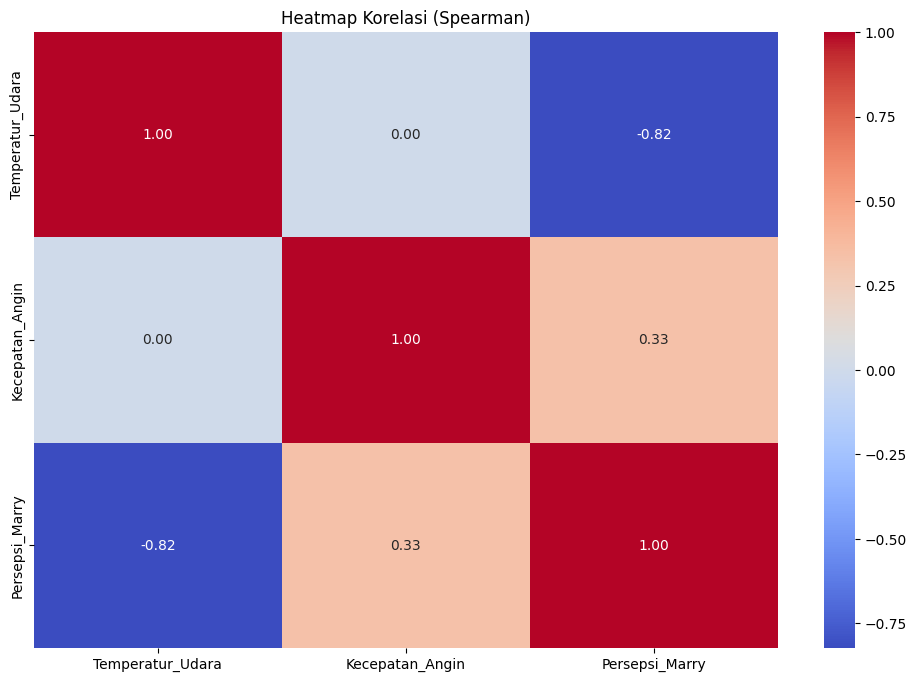

In [157]:
correlation_matrix = df_mary.corr(method='spearman')

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Korelasi (Spearman)")
plt.show()

In [158]:
X = df_mary.drop(columns=['Persepsi_Marry'])
y = df_mary['Persepsi_Marry']

In [159]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42,stratify=y)

In [160]:
cv = 3

# K maksimal HARUS lebih kecil atau sama dengan jumlah data latih terkecil
max_k = 5   # langsung pakai angka 5 supaya aman

neighbors = range(1, max_k + 1)
cv_scores = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=cv)
    cv_scores.append(scores.mean())

optimal_k = neighbors[np.argmax(cv_scores)]
best_accuracy = np.max(cv_scores)

print("\n--- Hasil Uji Akurasi ---")
for k, score in zip(neighbors, cv_scores):
    print(f"k = {k}: akurasi = {score:.4f}")

print(f"\n➡️ Nilai k terbaik: {optimal_k} (akurasi: {best_accuracy:.4f})")


--- Hasil Uji Akurasi ---
k = 1: akurasi = 0.8889
k = 2: akurasi = 0.6111
k = 3: akurasi = 0.6111
k = 4: akurasi = 0.5000
k = 5: akurasi = 0.3889

➡️ Nilai k terbaik: 1 (akurasi: 0.8889)


In [161]:
# Melatih Model
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [162]:
data_baru = pd.DataFrame({
    'Temperatur_Udara': [16],
    'Kecepatan_Angin': [3]
})

# Lakukan Prediksi
test = model.predict(data_baru)

In [163]:
# Asumsi Anda sudah memiliki X_test dan y_test dari pembagian data sebelumnya

# Melakukan Prediksi pada Data Uji
y_pred = model.predict(X_test)

# Mengukur Akurasi
from sklearn.metrics import accuracy_score, classification_report

# Hitung akurasi
accuracy = accuracy_score(y_test, y_pred)

print("--- Hasil Uji Performa Model ---")
print(f"Akurasi Model pada Data Uji: {accuracy:.2f}")

# Menampilkan laporan klasifikasi lengkap
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

--- Hasil Uji Performa Model ---
Akurasi Model pada Data Uji: 1.00

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [164]:
test

array([1])

# **Latihan 2**

In [15]:
# Data Sebenarnya (y_true) dan Hasil Prediksi (y_pred)
# 5 'Lulus' dan 5 'Tidak Lulus'
y_true = np.array(['Lulus', 'Lulus', 'Lulus', 'Lulus', 'Lulus',
                   'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus'])

y_pred = np.array(['Lulus', 'Lulus', 'Lulus', 'Tidak Lulus', 'Tidak Lulus',
                   'Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus'])

# Definisikan label: Kita tetapkan 'Lulus' sebagai kelas positif
labels = ['Tidak Lulus', 'Lulus']

print("\n Clasification Report")
print(classification_report(y_true, y_pred))


 Clasification Report
              precision    recall  f1-score   support

       Lulus       0.75      0.60      0.67         5
 Tidak Lulus       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



In [16]:
labels = ['Lulus', 'Tidak Lulus']


## 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Tampilkan Confusion Matrix dalam bentuk tabel
cm_df = pd.DataFrame(cm,
                     index=[f'Sebenarnya: {l}' for l in labels],
                     columns=[f'Prediksi: {l}' for l in labels])

print("--- 1. Confusion Matrix ---")
print(cm_df)

--- 1. Confusion Matrix ---
                         Prediksi: Lulus  Prediksi: Tidak Lulus
Sebenarnya: Lulus                      3                      2
Sebenarnya: Tidak Lulus                1                      4


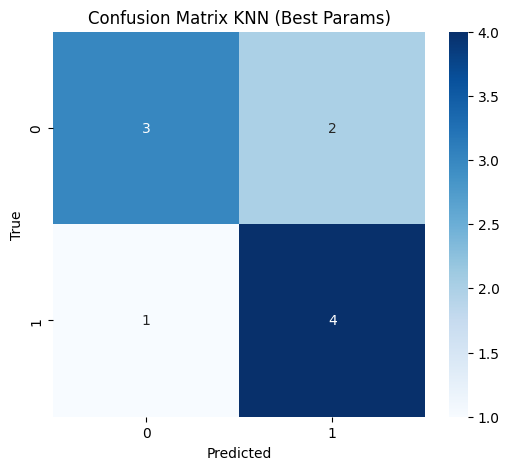

In [17]:
# Evaluasi dengan cunfosion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix KNN (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# **Latihan 3**

In [195]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1EkCNlLJ-3HaqN6hgAAqjxDkP8AU1JbRa")

In [196]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [198]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [199]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


In [200]:
df.duplicated().sum()

np.int64(0)

In [201]:
df['Season'].unique()

array(['Winter', 'Spring', 'Summer', 'Autumn'], dtype=object)

In [202]:
df['Weather Type'].unique()

array(['Rainy', 'Cloudy', 'Sunny', 'Snowy'], dtype=object)

In [203]:
df['Cloud Cover'].unique()

array(['partly cloudy', 'clear', 'overcast', 'cloudy'], dtype=object)

In [204]:
df['Location'].unique()

array(['inland', 'mountain', 'coastal'], dtype=object)

In [205]:
le = LabelEncoder()

for col in ['Season', 'Weather Type', 'Cloud Cover', 'Location']:
    df[col] = le.fit_transform(df[col])

In [206]:
print(df['Season'].unique())
print(df['Weather Type'].unique())
print(df['Cloud Cover'].unique())
print(df['Location'].unique())

[3 1 2 0]
[1 0 3 2]
[3 0 2 1]
[1 2 0]


In [207]:
df['Weather Type'].value_counts()

,count
Weather Type,
1,3300
0,3300
3,3300
2,3300


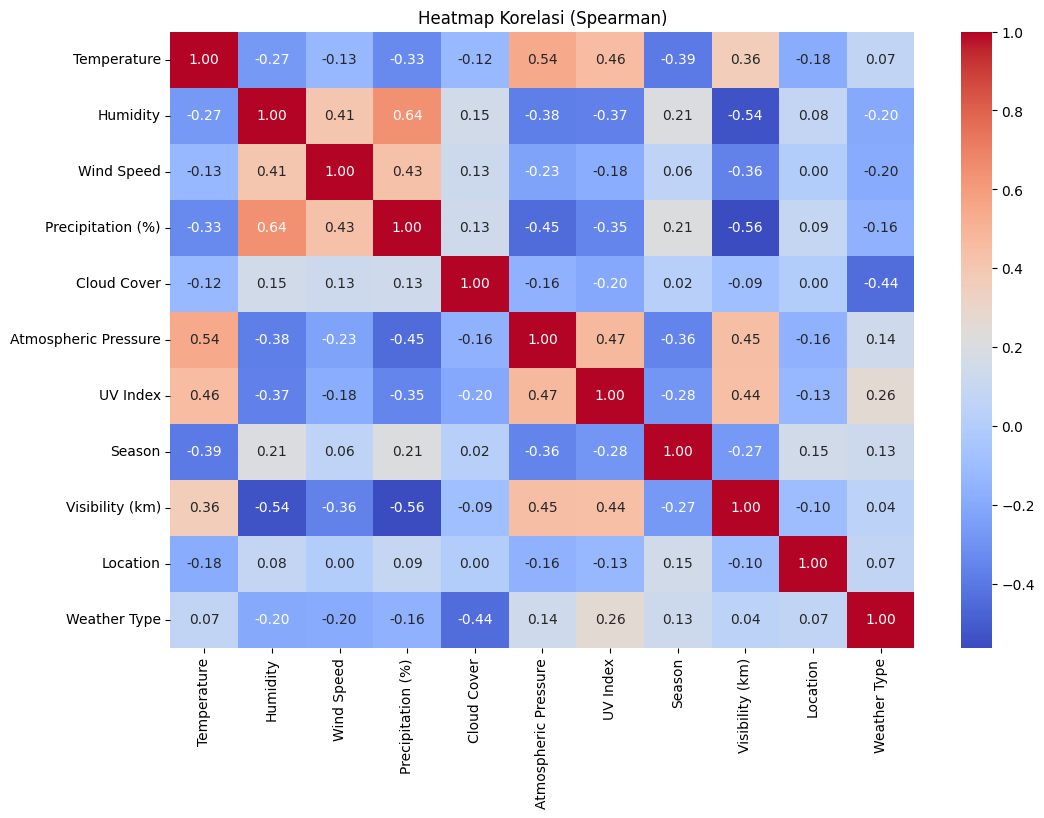

In [208]:
# Menghitung matriks korelasi menggunakan Spearman
correlation_matrix = df.corr(method='spearman')

# Membuat heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Korelasi (Spearman)")
plt.show()

/tmp/ipython-input-2335435455.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weather Type', data=df, palette='Set2')


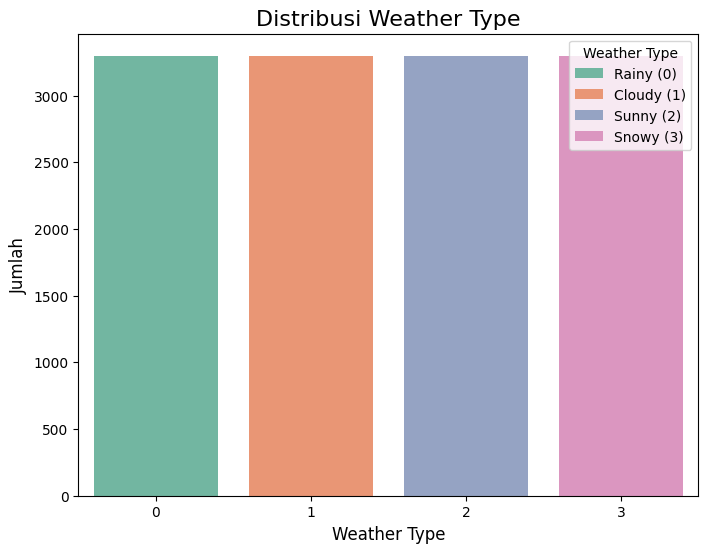

In [209]:
# Membuat diagram batang untuk Weather Type
plt.figure(figsize=(8, 6))
sns.countplot(x='Weather Type', data=df, palette='Set2')

# Menambahkan judul dan label
plt.title('Distribusi Weather Type', fontsize=16)
plt.xlabel('Weather Type', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

# Menambahkan legend (adjusted labels for correctness)
plt.legend(title='Weather Type', labels=['Rainy (0)', 'Cloudy (1)', 'Sunny (2)', 'Snowy (3)'], loc='upper right')

# Menampilkan plot
plt.show()

In [210]:
# Menentukan Pembagian fitur dan target, mana yang kan menjadi fitur dan mana yang menjadi target
x = df.drop(columns=['Weather Type'])
y = df['Weather Type']

In [211]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42)

In [212]:
#Melihat dimensi data latih dan testing
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(10560, 10) (10560,) (2640, 10) (2640,)


In [213]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [214]:
# Melatih Model
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [215]:
y_pred = model.predict(x_test_scaled)

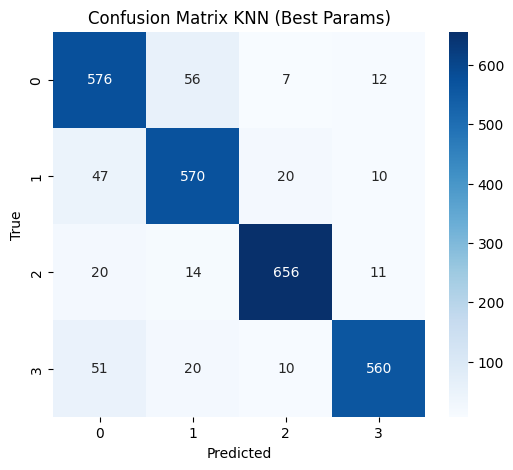

In [216]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix KNN (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [217]:
# Mencari parameter terbaik untuk digunakan
param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid.fit(x_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score (CV):", grid.best_score_)

Best Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best Score (CV): 0.8958333333333334


In [218]:
# Melatih model KKN terbaik dan lakukan prediksi
best_knn = grid.best_estimator_
best_knn.fit(x_train_scaled, y_train)

# Prediksi
y_pred = best_knn.predict(x_test_scaled)

In [219]:
print("\n Clasification Report")
print(classification_report(y_test, y_pred))



 Clasification Report
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       651
           1       0.86      0.89      0.87       647
           2       0.93      0.94      0.94       701
           3       0.91      0.89      0.90       641

    accuracy                           0.89      2640
   macro avg       0.89      0.89      0.89      2640
weighted avg       0.89      0.89      0.89      2640



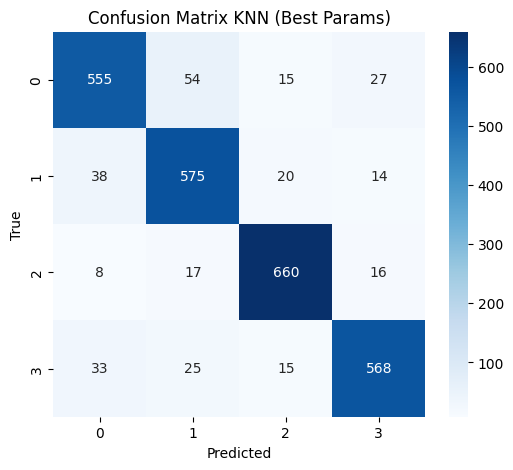

In [220]:
# Evaluasi dengan cunfosion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix KNN (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [221]:
# Validasi cross validation
cv_scores = cross_val_score(best_knn, x_train_scaled, y_train, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross Validation Accuracy: 0.8967803030303031
Std Dev: 0.006749443061062664


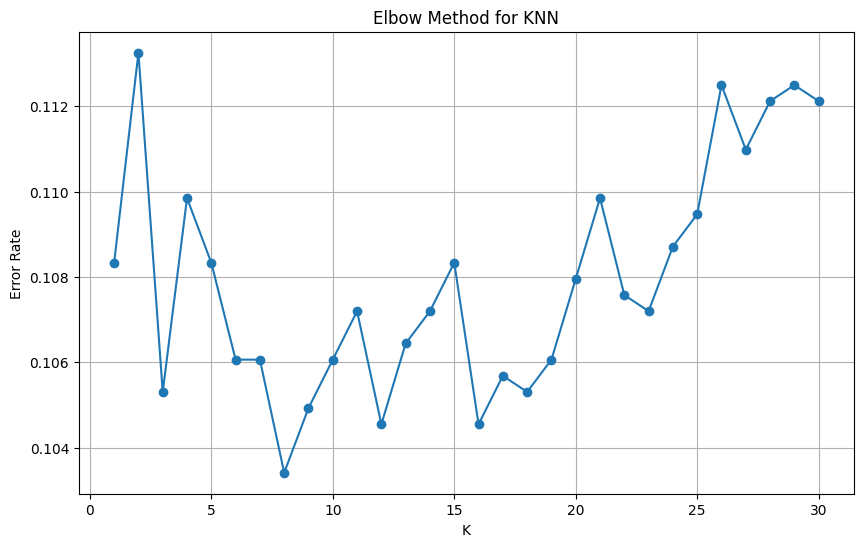

In [222]:
# Menentukan Nilai K Optimal dengan Elbow Method
errors = []

for k in range(1, 31):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(x_train_scaled, y_train)
    pred = knn_temp.predict(x_test_scaled)
    errors.append(np.mean(pred != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1, 31), errors, marker='o')
plt.title("Elbow Method for KNN")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()